<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/05_05_exact_DMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Mode Decomposition (DMD)

This notebook introduces **exact DMD** step by step using a simple toy problem.

We will:
1. generate a clean dataset with known underlying dynamics,
2. build the snapshot matrices,
3. compute the SVD,
4. form the reduced operator,
5. compute eigenvalues and DMD modes,
6. reconstruct the data,
7. add measurement noise and repeat the analysis.

The goal is to make every step visible rather than calling a black-box DMD package.

## 1. Imports and plotting settings

We only use standard scientific Python tools that run directly in Google Colab.

In [67]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 120

## 2. Build a toy dataset with known dynamics

We create a **hidden two-state linear system**
$$
\mathbf{z}_{k+1} = A \mathbf{z}_k
$$
with a decaying oscillation. We then map that 2D state into a higher-dimensional measured field
$$
\mathbf{x}_k = \mathbf{g}_1 z_{1,k} + \mathbf{g}_2 z_{2,k}.
$$

This gives us a dataset that looks more like a spatially distributed measurement while still having simple, exactly known latent dynamics.

### Chosen parameters

We use:
- growth/decay rate: $\sigma = -0.2~\mathrm{s}^{-1}$
- angular frequency: $\omega = 4~\mathrm{rad/s}$
- time step: $\Delta t = 0.1~\mathrm{s}$

The exact discrete-time eigenvalues should be
$$
\lambda_{1,2} = e^{(\sigma \pm i\omega)\Delta t}.
$$

In [68]:
# Time and space settings
dt = 0.1
m = 80                    # number of snapshots
t = np.arange(m) * dt

n_space = 60
x_space = np.linspace(0.0, 1.0, n_space)

# Continuous-time parameters of the hidden 2D system
sigma_true = -0.2         # decay rate [1/s]
omega_true = 4.0          # angular frequency [rad/s]

# Discrete-time system matrix: decaying rotation
A_true = np.exp(sigma_true * dt) * np.array([
    [np.cos(omega_true * dt), -np.sin(omega_true * dt)],
    [np.sin(omega_true * dt),  np.cos(omega_true * dt)]
])

# Expected discrete-time eigenvalues
lambda_true = np.linalg.eigvals(A_true)

print("A_true =")
print(A_true)
print("\nExpected discrete-time eigenvalues:")
print(lambda_true)

A_true =
[[ 0.9028 -0.3817]
 [ 0.3817  0.9028]]

Expected discrete-time eigenvalues:
[0.9028+0.3817j 0.9028-0.3817j]


## 3. Generate the latent state and the measured field

The hidden state is two-dimensional, but the measured snapshots are 60-dimensional.

This is useful because:
- the data matrix is now tall enough for an informative SVD,
- the true clean data are still rank 2,
- DMD should recover the same oscillatory-decaying dynamics from the measured field.

In [69]:
# Generate the hidden 2D state z_k
Z = np.zeros((2, m))
Z[:, 0] = np.array([1.5, -0.2])

for k in range(1, m):
    Z[:, k] = A_true @ Z[:, k - 1]

# Define two spatial patterns g1(x) and g2(x)
g1 = np.sin(np.pi * x_space)
g2 = 0.6 * np.cos(2 * np.pi * x_space) + 0.3 * np.sin(3 * np.pi * x_space)

# Build measured snapshots X[:, k] = g1 * z1_k + g2 * z2_k
X_clean = np.outer(g1, Z[0, :]) + np.outer(g2, Z[1, :])

print("Shape of X_clean:", X_clean.shape)

Shape of X_clean: (60, 80)


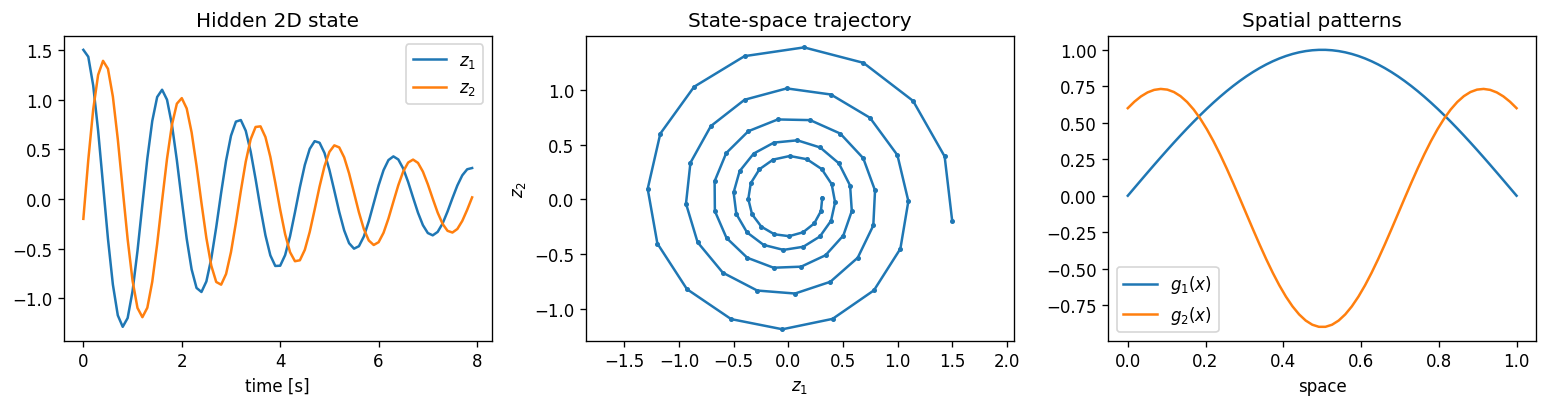

In [70]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

ax[0].plot(t, Z[0, :], label=r"$z_1$")
ax[0].plot(t, Z[1, :], label=r"$z_2$")
ax[0].set_title("Hidden 2D state")
ax[0].set_xlabel("time [s]")
ax[0].legend()

ax[1].plot(Z[0, :], Z[1, :], "-o", markersize=2)
ax[1].set_title("State-space trajectory")
ax[1].set_xlabel(r"$z_1$")
ax[1].set_ylabel(r"$z_2$")
ax[1].axis("equal")

ax[2].plot(x_space, g1, label=r"$g_1(x)$")
ax[2].plot(x_space, g2, label=r"$g_2(x)$")
ax[2].set_title("Spatial patterns")
ax[2].set_xlabel("space")
ax[2].legend()

plt.tight_layout()
plt.show()

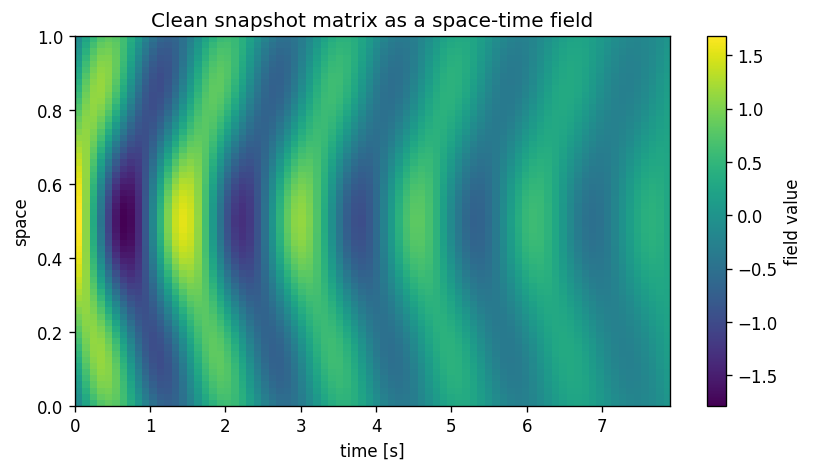

In [71]:
plt.figure(figsize=(8, 4))
plt.imshow(
    X_clean,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x_space[0], x_space[-1]]
)
plt.colorbar(label="field value")
plt.xlabel("time [s]")
plt.ylabel("space")
plt.title("Clean snapshot matrix as a space-time field")
plt.show()

## 4. Construct the snapshot matrices $X_1$ and $X_2$

Exact DMD assumes
$$
X_2 \approx A X_1,
$$
where
$$
X_1 = \begin{bmatrix}\mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_{m-1}\end{bmatrix},
\qquad
X_2 = \begin{bmatrix}\mathbf{x}_2 & \mathbf{x}_3 & \cdots & \mathbf{x}_{m}\end{bmatrix}.
$$

Each column is a snapshot, and each column pair represents a one-step time shift.

In [72]:
X1 = X_clean[:, :-1]
X2 = X_clean[:, 1:]

print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)

X1 shape: (60, 79)
X2 shape: (60, 79)


## 5. Compute the SVD of $X_1$

We factor
$$
X_1 = U \Sigma V^*.
$$

For the clean dataset, the true latent dynamics are two-dimensional, so we expect the clean data to be essentially rank 2.

In [73]:
U, s, Vh = np.linalg.svd(X1, full_matrices=False)

print("First 10 singular values:")
print(s[:10])

First 10 singular values:
[30.6226 22.0522  0.      0.      0.      0.      0.      0.      0.
  0.    ]


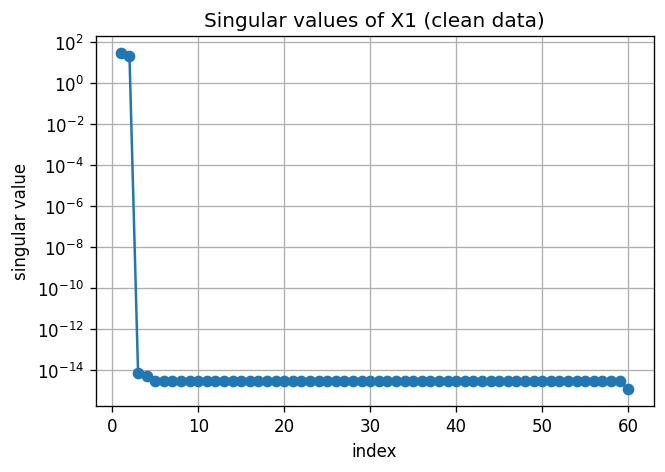

In [74]:
plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(1, len(s) + 1), s, "o-")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of X1 (clean data)")
plt.grid(True)
plt.show()

## 6. Choose a truncation rank $r$

For the clean data, the first two singular values dominate strongly, so we choose
$$
r = 2.
$$

This means we project the dynamics onto the leading two-dimensional subspace.

In [75]:
r = 2

Ur = U[:, :r]
Sr = np.diag(s[:r])
Vr = Vh.conj().T[:, :r]

print("Ur shape:", Ur.shape)
print("Sr shape:", Sr.shape)
print("Vr shape:", Vr.shape)

Ur shape: (60, 2)
Sr shape: (2, 2)
Vr shape: (79, 2)


## 7. Form the reduced operator $\widetilde{A}$

The exact DMD reduced operator is
$$
\widetilde{A} = U_r^* X_2 V_r \Sigma_r^{-1}.
$$

This is the low-dimensional approximation of the snapshot-to-snapshot evolution operator.

In [76]:
A_tilde = Ur.conj().T @ X2 @ Vr @ np.linalg.inv(Sr)

print("A_tilde =")
print(A_tilde)

A_tilde =
[[ 0.8836  0.5365]
 [-0.2722  0.922 ]]


## 8. Eigendecomposition of the reduced operator

We solve
$$
\widetilde{A} W = W \Lambda.
$$

The diagonal entries of $\Lambda$ are the DMD eigenvalues.

In [77]:
eigvals, W = np.linalg.eig(A_tilde)

print("DMD eigenvalues:")
print(eigvals)

DMD eigenvalues:
[0.9028+0.3817j 0.9028-0.3817j]


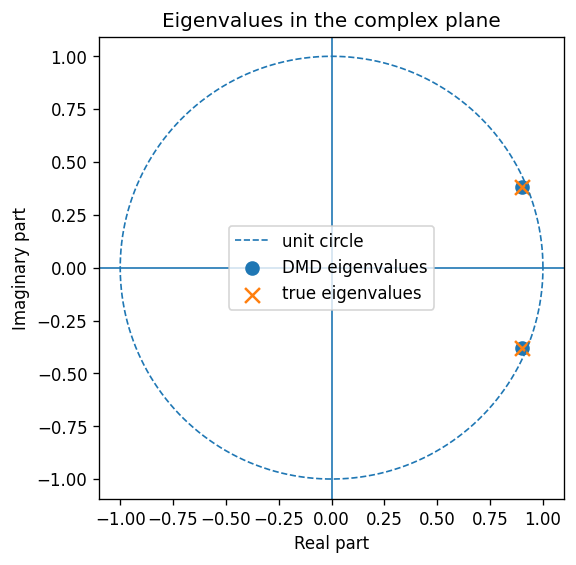

In [78]:
theta = np.linspace(0, 2 * np.pi, 400)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), "--", linewidth=1, label="unit circle")
plt.scatter(eigvals.real, eigvals.imag, s=60, label="DMD eigenvalues")
plt.scatter(lambda_true.real, lambda_true.imag, marker="x", s=80, label="true eigenvalues")
plt.axhline(0.0, linewidth=1)
plt.axvline(0.0, linewidth=1)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues in the complex plane")
plt.axis("equal")
plt.legend()
plt.show()

## 9. Compute the exact DMD modes

The **exact DMD modes** are
$$
\Phi = X_2 V_r \Sigma_r^{-1} W.
$$

These modes live in the original data space, so they can be interpreted as spatial structures.

In [79]:
Phi = X2 @ Vr @ np.linalg.inv(Sr) @ W

print("Phi shape:", Phi.shape)

Phi shape: (60, 2)


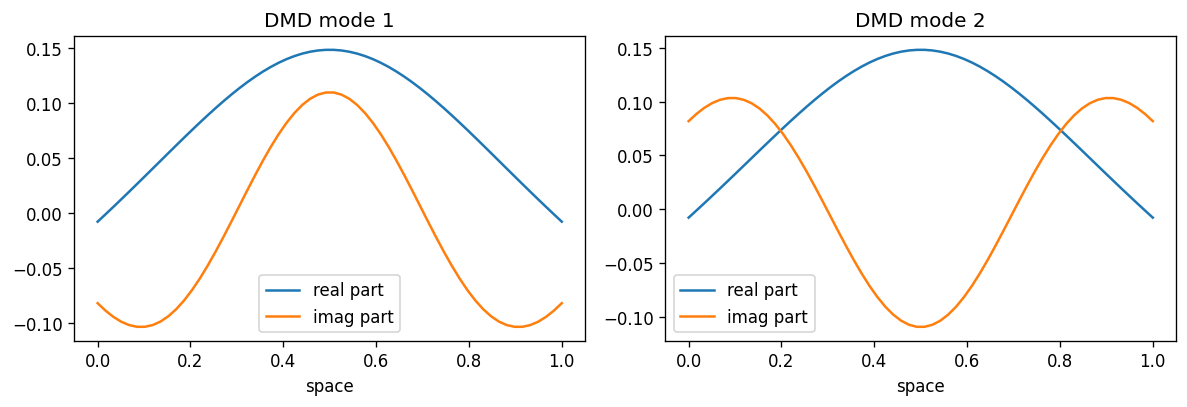

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].plot(x_space, Phi[:, 0].real, label="real part")
ax[0].plot(x_space, Phi[:, 0].imag, label="imag part")
ax[0].set_title("DMD mode 1")
ax[0].set_xlabel("space")
ax[0].legend()

ax[1].plot(x_space, Phi[:, 1].real, label="real part")
ax[1].plot(x_space, Phi[:, 1].imag, label="imag part")
ax[1].set_title("DMD mode 2")
ax[1].set_xlabel("space")
ax[1].legend()

plt.tight_layout()
plt.show()

## 10. Convert eigenvalues to continuous-time growth rates and frequencies

The discrete-time DMD eigenvalues tell us how a mode evolves from one snapshot to the next.  
To interpret them physically, we convert them using
$$
\omega_j = \frac{\log(\lambda_j)}{\Delta t}.
$$

Then:
- $\Re(\omega_j)$ is the growth/decay rate,
- $\Im(\omega_j)$ is the angular frequency in rad/s,
- $\Im(\omega_j)/(2\pi)$ is the frequency in Hz.

In [81]:
omega_dmd = np.log(eigvals) / dt
freq_dmd = omega_dmd.imag / (2 * np.pi)

print("Continuous-time DMD eigenvalues omega:")
print(omega_dmd)

print("\nGrowth/decay rates [1/s]:")
print(omega_dmd.real)

print("\nAngular Frequencies [rad/s]:")
print(omega_dmd.imag)

print("\nFrequencies [Hz]:")
print(freq_dmd)

Continuous-time DMD eigenvalues omega:
[-0.2+4.j -0.2-4.j]

Growth/decay rates [1/s]:
[-0.2 -0.2]

Angular Frequencies [rad/s]:
[ 4. -4.]

Frequencies [Hz]:
[ 0.6366 -0.6366]


## 11. Compute modal amplitudes

We determine the modal amplitudes from the first snapshot:
$$
\mathbf{x}_1 \approx \Phi \mathbf{b},
\qquad
\mathbf{b} = \Phi^\dagger \mathbf{x}_1.
$$

These amplitudes tell us how strongly each DMD mode is present initially.

In [82]:
x1_initial = X_clean[:, 0]
b = np.linalg.lstsq(Phi, x1_initial, rcond=None)[0]

print("Modal amplitudes b:")
print(b)

Modal amplitudes b:
[5.5218-0.2028j 5.5218+0.2028j]


## 12. Reconstruct the data from the DMD model

Using
$$
\mathbf{x}(t_k) \approx \sum_{j=1}^{r} b_j \boldsymbol{\phi}_j e^{\omega_j t_k},
$$
we reconstruct every snapshot.

For the clean dataset, the reconstruction should be extremely accurate because the data were generated from an exactly rank-2 linear system.

In [83]:
time_dynamics = np.zeros((r, m), dtype=complex)

for k, tk in enumerate(t):
    time_dynamics[:, k] = b * np.exp(omega_dmd * tk)

X_dmd_clean = Phi @ time_dynamics
relative_error_clean = np.linalg.norm(X_clean - X_dmd_clean.real) / np.linalg.norm(X_clean)

print("Relative reconstruction error (clean case):", relative_error_clean)

Relative reconstruction error (clean case): 1.0542120167121887e-14


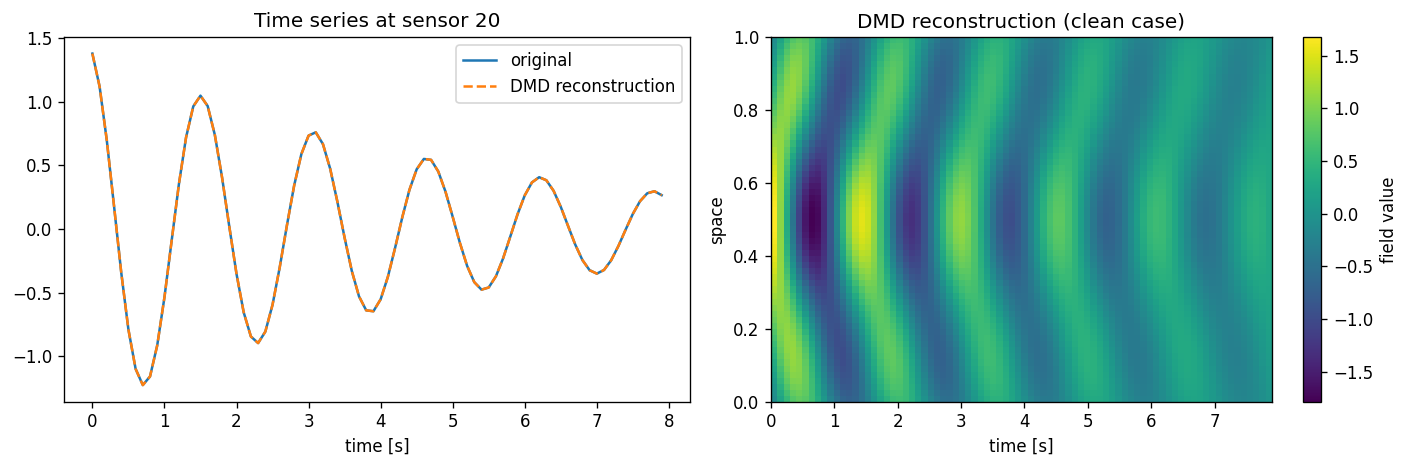

In [84]:
sensor_index = 20

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, X_clean[sensor_index, :], label="original")
ax[0].plot(t, X_dmd_clean.real[sensor_index, :], "--", label="DMD reconstruction")
ax[0].set_title(f"Time series at sensor {sensor_index}")
ax[0].set_xlabel("time [s]")
ax[0].legend()

im = ax[1].imshow(
    X_dmd_clean.real,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x_space[0], x_space[-1]]
)
ax[1].set_title("DMD reconstruction (clean case)")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("space")
fig.colorbar(im, ax=ax[1], label="field value")

plt.tight_layout()
plt.show()

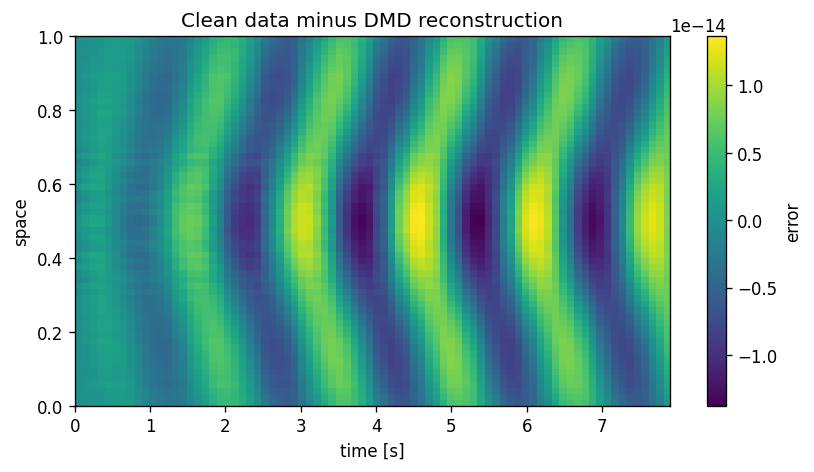

In [85]:
plt.figure(figsize=(8, 4))
plt.imshow(
    X_clean - X_dmd_clean.real,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x_space[0], x_space[-1]]
)
plt.colorbar(label="error")
plt.xlabel("time [s]")
plt.ylabel("space")
plt.title("Clean data minus DMD reconstruction")
plt.show()

## 13. Add measurement noise and repeat the analysis

Now we contaminate the measured field with Gaussian noise.

This is important because exact DMD is sensitive to:
- noise in the snapshots,
- rank truncation decisions,
- small singular values and numerical conditioning.

We will keep the same rank $r=2$ because we know the clean latent system has two dominant coordinates.

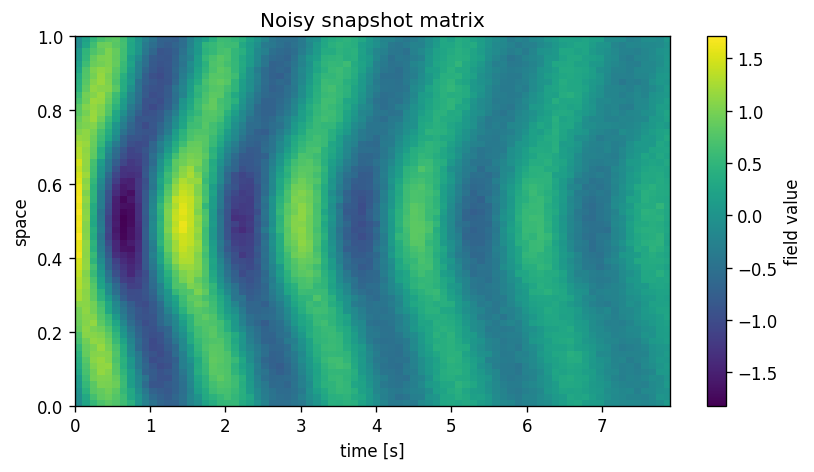

In [86]:
rng = np.random.default_rng(7)

noise_level = 0.08   # relative to the standard deviation of the clean data
X_noisy = X_clean + noise_level * np.std(X_clean) * rng.standard_normal(X_clean.shape)

plt.figure(figsize=(8, 4))
plt.imshow(
    X_noisy,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x_space[0], x_space[-1]]
)
plt.colorbar(label="field value")
plt.xlabel("time [s]")
plt.ylabel("space")
plt.title("Noisy snapshot matrix")
plt.show()

### 13.1 Snapshot matrices for the noisy data

In [87]:
X1n = X_noisy[:, :-1]
X2n = X_noisy[:, 1:]

### 13.2 SVD of the noisy data

Unlike the clean case, noisy data are no longer exactly rank 2.  
You should see a nonzero tail in the singular values.

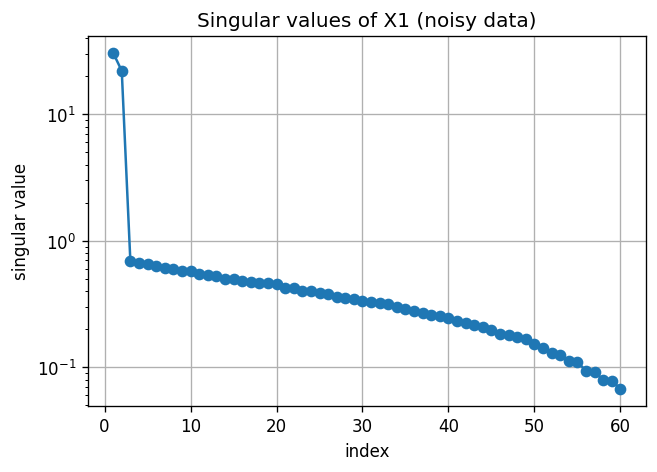

First 10 singular values for noisy data:
[30.5632 22.0471  0.6934  0.6712  0.6513  0.6365  0.6092  0.6006  0.5775
  0.5732]


In [88]:
Un, sn, Vhn = np.linalg.svd(X1n, full_matrices=False)

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(1, len(sn) + 1), sn, "o-")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of X1 (noisy data)")
plt.grid(True)
plt.show()

print("First 10 singular values for noisy data:")
print(sn[:10])

### 13.3 Truncate to rank $r=2$ and rebuild the DMD model

We repeat the same exact DMD steps using the noisy data.

In [89]:
rn = 2

Urn = Un[:, :rn]
Srn = np.diag(sn[:rn])
Vrn = Vhn.conj().T[:, :rn]

A_tilde_n = Urn.conj().T @ X2n @ Vrn @ np.linalg.inv(Srn)
eigvals_n, Wn = np.linalg.eig(A_tilde_n)
Phi_n = X2n @ Vrn @ np.linalg.inv(Srn) @ Wn

omega_n = np.log(eigvals_n) / dt
freq_n = omega_n.imag / (2 * np.pi)

b_n = np.linalg.lstsq(Phi_n, X_noisy[:, 0], rcond=None)[0]

time_dynamics_n = np.zeros((rn, m), dtype=complex)
for k, tk in enumerate(t):
    time_dynamics_n[:, k] = b_n * np.exp(omega_n * tk)

X_dmd_noisy = Phi_n @ time_dynamics_n

relative_error_noisy = np.linalg.norm(X_clean - X_dmd_noisy.real) / np.linalg.norm(X_clean)

print("Noisy-case DMD eigenvalues:")
print(eigvals_n)

print("\nContinuous-time growth rates [1/s]:")
print(omega_n.real)

print("\nContinuous-time frequencies [Hz]:")
print(freq_n)

print("\nRelative reconstruction error against clean data:", relative_error_noisy)

Noisy-case DMD eigenvalues:
[0.9025+0.3813j 0.9025-0.3813j]

Continuous-time growth rates [1/s]:
[-0.2046 -0.2046]

Continuous-time frequencies [Hz]:
[ 0.6363 -0.6363]

Relative reconstruction error against clean data: 0.017221802335660695


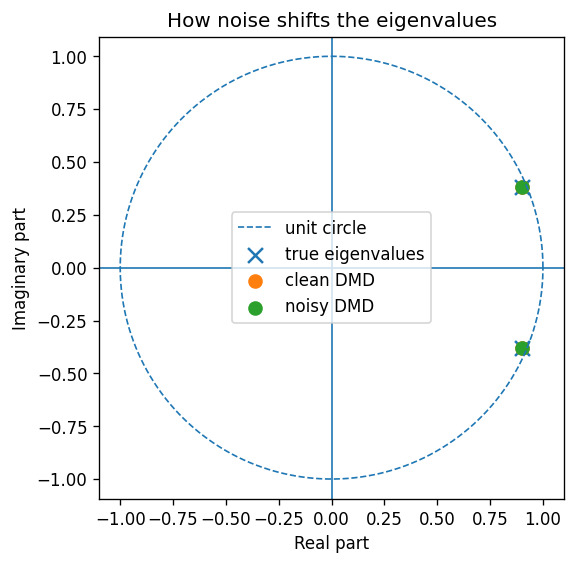

In [90]:
theta = np.linspace(0, 2 * np.pi, 400)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), "--", linewidth=1, label="unit circle")
plt.scatter(lambda_true.real, lambda_true.imag, marker="x", s=80, label="true eigenvalues")
plt.scatter(eigvals.real, eigvals.imag, s=60, label="clean DMD")
plt.scatter(eigvals_n.real, eigvals_n.imag, s=60, label="noisy DMD")
plt.axhline(0.0, linewidth=1)
plt.axvline(0.0, linewidth=1)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("How noise shifts the eigenvalues")
plt.axis("equal")
plt.legend()
plt.show()

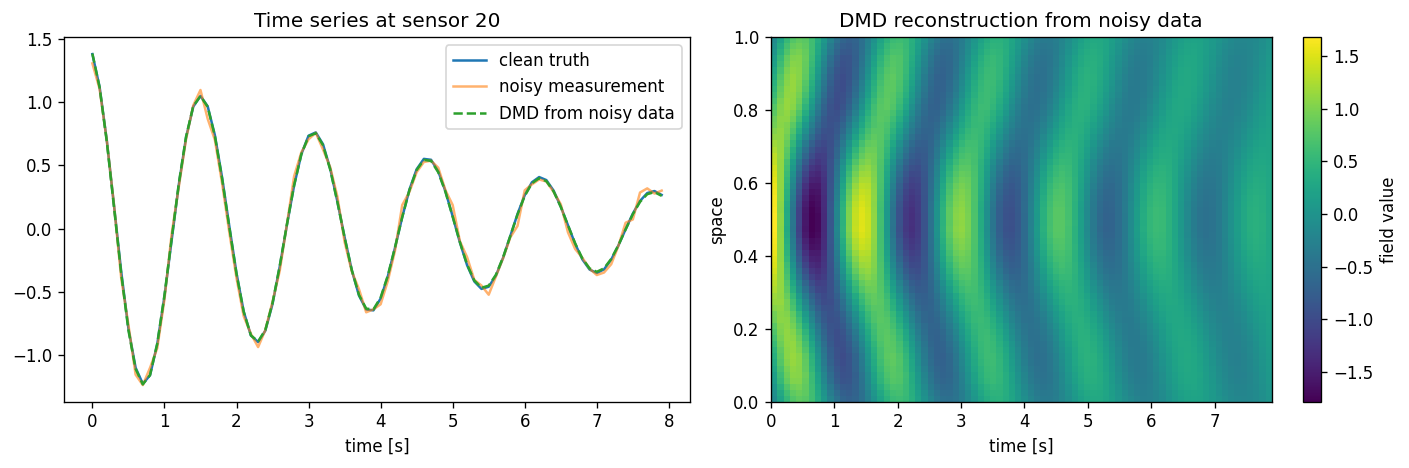

In [91]:
sensor_index = 20

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, X_clean[sensor_index, :], label="clean truth")
ax[0].plot(t, X_noisy[sensor_index, :], alpha=0.6, label="noisy measurement")
ax[0].plot(t, X_dmd_noisy.real[sensor_index, :], "--", label="DMD from noisy data")
ax[0].set_title(f"Time series at sensor {sensor_index}")
ax[0].set_xlabel("time [s]")
ax[0].legend()

im = ax[1].imshow(
    X_dmd_noisy.real,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x_space[0], x_space[-1]]
)
ax[1].set_title("DMD reconstruction from noisy data")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("space")
fig.colorbar(im, ax=ax[1], label="field value")

plt.tight_layout()
plt.show()

## 14. Short discussion: what changed after adding noise?

A few things should stand out:

1. **The singular value spectrum changed.**  
    <details>
    <summary>Click to show/hide text</summary>
      The clean dataset was essentially rank 2, but the noisy dataset has a nonzero singular-value tail.
    </details>

2. **The eigenvalues moved.**  
    <details>
    <summary>Click to show/hide text</summary>
      The noisy DMD eigenvalues are close to the true values, but not exact. This changes the inferred decay rate and frequency.
    </details>

3. **The reconstruction is no longer exact.**  
    <details>
    <summary>Click to show/hide text</summary>
      Exact DMD is fitting a best linear model to noisy data, so reconstruction error increases.
    </details>


4. **Rank selection now matters more.**  
    <details>
    <summary>Click to show/hide text</summary>
       In the clean case, rank 2 was obvious. In the noisy case, choosing the rank becomes part of the modeling decision.
    </details>


This is a good first example of a central lesson in data-driven modeling:
<details>
<summary>Click to show/hide text</summary>
> the method, the data quality, and the modeling assumptions all matter.
</details>



## 15. Exercise for students

Try the following modifications:
- increase the noise level and observe how the eigenvalues move,
- change the rank from $r=2$ to $r=3$ or $r=4$,
- reduce the number of snapshots,
- change the sampling interval $\Delta t$ and see how frequency estimation changes.

These experiments will help you understand why exact DMD is useful, but also why it can be fragile.